In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
from pathlib import Path
import sys
import importlib

INPUTS_ROOT = Path('/content/drive/MyDrive/Colab_Notebooks/crowd-enVent')
PROJECT_ROOT = Path('/content/drive/MyDrive/2026-1/NLP/appraisal/nlp-appraisal/')
OUTPUTS_PATH = PROJECT_ROOT / 'data'

if str(PROJECT_ROOT)  not in sys.path: 
    sys.path.insert(0, str(PROJECT_ROOT))


Generators wrote the texts and labeled their own appraisals. We look at this file first: 

In [22]:
import pandas as pd
gen_df = pd.read_csv(INPUTS_ROOT / 'corpus/crowd-enVent_generation.tsv', sep='\t')

In [23]:
gen_df.describe()
gen_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6600 entries, 0 to 6599
Data columns (total 61 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   round_number            6600 non-null   object 
 1   emotion                 6600 non-null   object 
 2   text_id                 6600 non-null   int64  
 3   timestamp               6600 non-null   object 
 4   prolific_id             6600 non-null   object 
 5   anger                   6600 non-null   int64  
 6   boredom                 6600 non-null   int64  
 7   disgust                 6600 non-null   int64  
 8   fear                    6600 non-null   int64  
 9   guilt                   6600 non-null   int64  
 10  joy                     6600 non-null   int64  
 11  pride                   6600 non-null   int64  
 12  relief                  6600 non-null   int64  
 13  sadness                 6600 non-null   int64  
 14  shame                   6600 non-null   

Checking distribution to inform choice of loss function and evaluation metrics: 

In [24]:
import src.config as config 
gen_df[config.TARGET_DIMS].describe()

,suddenness,familiarity,predict_event,pleasantness,unpleasantness,goal_relevance,chance_responsblt,self_responsblt,other_responsblt,predict_conseq,...,urgency,self_control,other_control,chance_control,accept_conseq,standards,social_norms,attention,not_consider,effort
count,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,...,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000
mean,3.129697,2.684545,2.857273,2.570455,3.173939,3.104697,2.268788,2.748182,3.185758,3.027727,...,3.234091,2.640000,3.378030,2.183333,3.117576,2.438939,1.792576,3.691364,2.548333,3.261212
std,1.542890,1.469353,1.473078,1.694202,1.704594,1.499642,1.506925,1.651363,1.656530,1.414745,...,1.473272,1.449385,1.523858,1.464339,1.428753,1.585441,1.325438,1.312182,1.570131,1.461309
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,...,2.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,3.000000,1.000000,2.000000
50%,3.000000,3.000000,3.000000,2.000000,4.000000,3.000000,1.000000,3.000000,4.000000,3.000000,...,3.000000,2.000000,4.000000,1.000000,3.000000,2.000000,1.000000,4.000000,2.000000,3.000000
75%,5.000000,4.000000,4.000000,5.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,...,5.000000,4.000000,5.000000,3.000000,4.000000,4.000000,2.000000,5.000000,4.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


array([[<Axes: title={'center': 'suddenness'}>,
        <Axes: title={'center': 'familiarity'}>,
        <Axes: title={'center': 'predict_event'}>,
        <Axes: title={'center': 'pleasantness'}>,
        <Axes: title={'center': 'unpleasantness'}>],
       [<Axes: title={'center': 'goal_relevance'}>,
        <Axes: title={'center': 'chance_responsblt'}>,
        <Axes: title={'center': 'self_responsblt'}>,
        <Axes: title={'center': 'other_responsblt'}>,
        <Axes: title={'center': 'predict_conseq'}>],
       [<Axes: title={'center': 'goal_support'}>,
        <Axes: title={'center': 'urgency'}>,
        <Axes: title={'center': 'self_control'}>,
        <Axes: title={'center': 'other_control'}>,
        <Axes: title={'center': 'chance_control'}>],
       [<Axes: title={'center': 'accept_conseq'}>,
        <Axes: title={'center': 'standards'}>,
        <Axes: title={'center': 'social_norms'}>,
        <Axes: title={'center': 'attention'}>,
        <Axes: title={'center': 'not_c

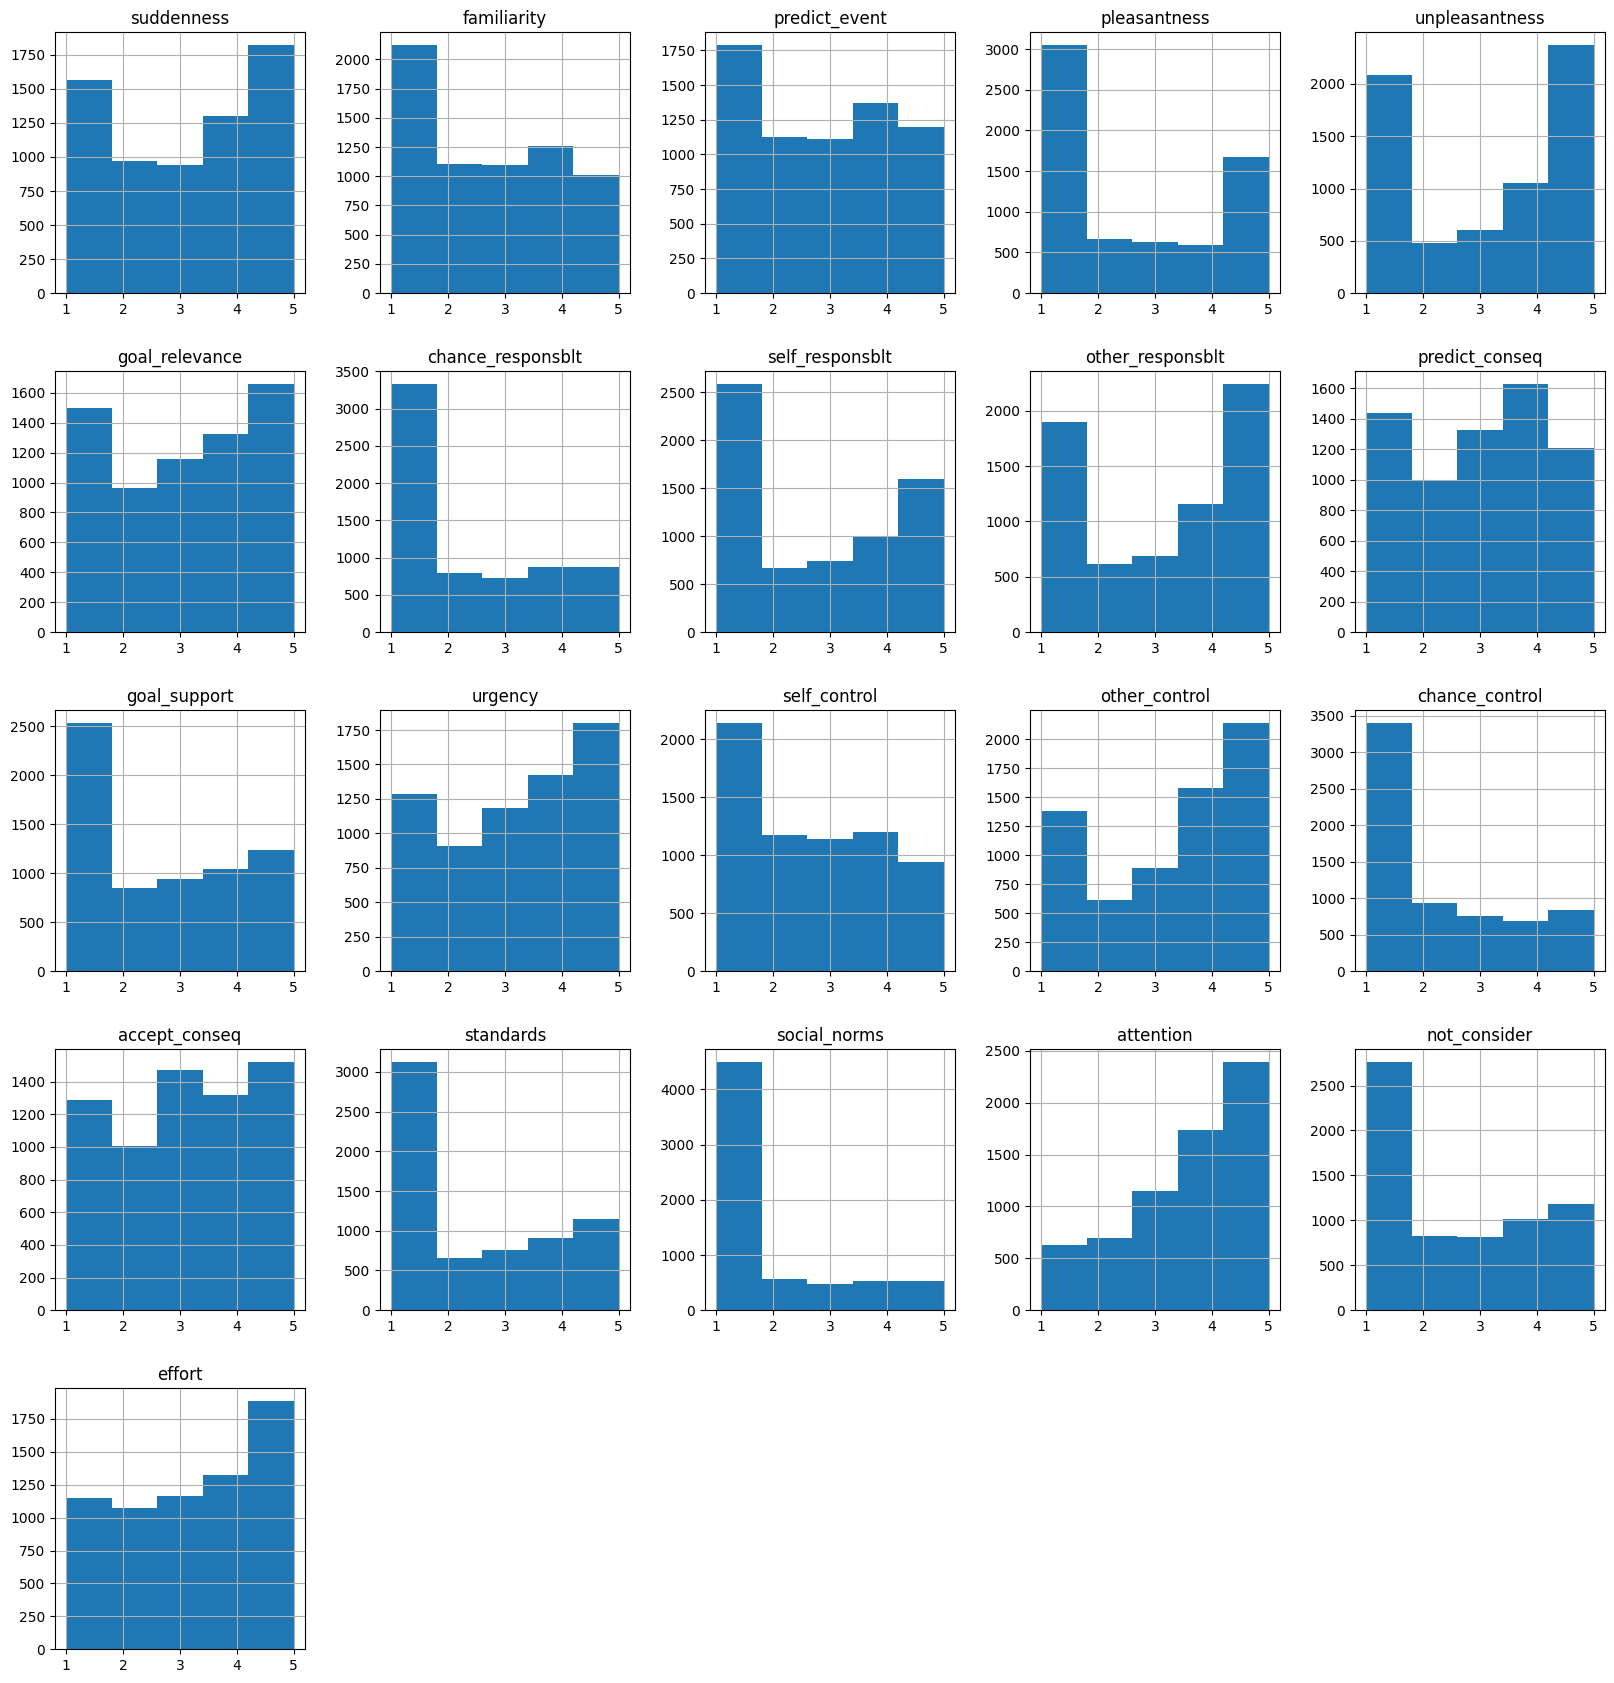

In [25]:
gen_df[config.TARGET_DIMS].hist(figsize=(20, 21), bins=5)

Examine the JSON weights file:

In [26]:

import json


weights_json = json.load(open('/content/drive/MyDrive/2026-1/NLP/appraisal/nlp-appraisal/data/dim_weights.json'))
for dim, weights in weights_json.items():
    print(f"Dimension: {dim}")
    sum_weights = sum(weights.values())
    print(f"  Sum of weights: {sum_weights:.4f}")
    for rating, weight in weights.items():
        print(f"  Rating {rating}: Weight {weight:.4f}")


Dimension: suddenness
  Sum of weights: 1.0000
  Rating 5: Weight 0.1327
  Rating 1: Weight 0.1549
  Rating 4: Weight 0.1866
  Rating 2: Weight 0.2584
  Rating 3: Weight 0.2673
Dimension: familiarity
  Sum of weights: 1.0000
  Rating 1: Weight 0.1136
  Rating 4: Weight 0.1939
  Rating 2: Weight 0.2170
  Rating 3: Weight 0.2239
  Rating 5: Weight 0.2515
Dimension: predict_event
  Sum of weights: 1.0000
  Rating 1: Weight 0.1427
  Rating 4: Weight 0.1886
  Rating 5: Weight 0.2125
  Rating 3: Weight 0.2268
  Rating 2: Weight 0.2294
Dimension: pleasantness
  Sum of weights: 1.0000
  Rating 1: Weight 0.0573
  Rating 5: Weight 0.1066
  Rating 3: Weight 0.2682
  Rating 2: Weight 0.2705
  Rating 4: Weight 0.2974
Dimension: unpleasantness
  Sum of weights: 1.0000
  Rating 5: Weight 0.0765
  Rating 1: Weight 0.0880
  Rating 4: Weight 0.1743
  Rating 3: Weight 0.2925
  Rating 2: Weight 0.3688
Dimension: goal_relevance
  Sum of weights: 1.0000
  Rating 5: Weight 0.1507
  Rating 1: Weight 0.1680
  

In [31]:
X_train = pd.read_csv(OUTPUTS_PATH / 'train.csv')
print(X_train.tail())

                                         generated_text  suddenness  \
4614  I read about the £80 cut to universal credit, ...        0.75   
4615                   I was rock climbing with friends        0.00   
4616  I accidentally broke my friends passenger seat...        1.00   
4617  I felt anger when spoken about in my presence ...        0.75   
4618                           My husband had an affair        1.00   

      familiarity  predict_event  pleasantness  unpleasantness  \
4614          0.5           0.75          0.00             1.0   
4615          0.5           0.50          0.75             0.0   
4616          0.0           0.00          0.00             1.0   
4617          0.5           0.75          0.00             1.0   
4618          0.0           0.00          0.00             1.0   

      goal_relevance  chance_responsblt  self_responsblt  other_responsblt  \
4614            1.00               0.00             0.00              1.00   
4615            0.00

Verify `AppraisalDataset` works correctly: 

In [33]:
from transformers import AutoTokenizer
from src.dataset import AppraisalDataset

tokenizer = AutoTokenizer.from_pretrained('roberta-base')

train_dataset = AppraisalDataset((OUTPUTS_PATH / 'train.csv'), tokenizer, weights_json, config.TARGET_DIMS)
print(train_dataset[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Map:   0%|          | 0/4619 [00:00<?, ? examples/s]

{'input_ids': tensor([   0,  100, 8102,  708,   94, 2289,   19,   10, 1441,    2,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0

Check token length distribution and find the best `max_length` before sticking to one:

In [34]:
# Compute the token length for every sample in the training set
token_lengths = X_train['generated_text'].apply(lambda x: len(tokenizer.encode(x, add_special_tokens=True)))

# Absolute max token length in the training set
max_token_length = token_lengths.max()
print(f"Absolute max token length in training set: {max_token_length}")

# Calculate how many have a token length longer than the current max_length
curr_max_length = 128
num_longer_than_max = (token_lengths > curr_max_length).sum() 
print(f"Number of samples with token length longer than {curr_max_length}: {num_longer_than_max} ({num_longer_than_max / len(X_train) * 100:.2f}%)")


Absolute max token length in training set: 473
Number of samples with token length longer than 128: 42 (0.91%)


In [35]:
print(token_lengths.median())
print(token_lengths.mean())

16.0
24.332539510716604
